# Module 2 — Analytics Pipeline
## Notebook 1: Profiling, Cleaning, and the Data Story

Loads the Titanic dataset **once** via `sns.load_dataset('titanic')`, saves it
as `titanic.csv` as an offline fallback, then performs full profiling,
missing-value handling, univariate + bivariate + multivariate EDA, and an
exploratory standardization sanity check.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
%matplotlib inline

## Task 1 — Load once and profile

In [2]:
# THE one and only load of the raw dataset.
df = sns.load_dataset("titanic")

# Save offline fallback immediately.
df.to_csv("titanic.csv", index=False)
print("Saved titanic.csv  ->  shape:", df.shape)

df.info()

Saved titanic.csv  ->  shape: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Shape:", df.shape)
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct})[missing > 0]

Shape: (891, 15)


,missing,pct
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


## Task 2 — Missing-value handling (threshold rule)

**Rule:** under 5% missing → drop those rows; 5%–30% missing → impute;
above 30% → decide to drop the column or encode "missing" as its own category,
with a written justification.

In [5]:
before = df.shape
df = df.copy()

# age: ~19.9% missing -> impute with median (5-30% band)
age_pct = df["age"].isna().mean() * 100
print(f"age missing: {age_pct:.2f}%  -> impute with median")
df["age"] = df["age"].fillna(df["age"].median())

# embarked: ~0.22% missing -> under 5% -> drop those rows
emb_pct = df["embarked"].isna().mean() * 100
print(f"embarked missing: {emb_pct:.2f}%  -> drop rows")
df = df.dropna(subset=["embarked"])

# embark_town mirrors embarked, same treatment already applied to embarked
# deck: ~77% missing -> drop the column (imputation would be unreliable)
deck_pct = df["deck"].isna().mean() * 100
print(f"deck missing: {deck_pct:.2f}%  -> drop the column")
df = df.drop(columns=["deck"])

print("Shape before:", before, "after:", df.shape)
print("Remaining missing:\n", df.isna().sum()[df.isna().sum() > 0])

age missing: 19.87%  -> impute with median
embarked missing: 0.22%  -> drop rows
deck missing: 77.39%  -> drop the column
Shape before: (891, 15) after: (889, 14)
Remaining missing:
 Series([], dtype: int64)


**Justification:**
- `age` (19.87% missing): falls in the 5–30% band → imputed with median.
  Median is robust to the right-skew we see later in the fare analysis.
- `embarked` (0.22% missing): under 5% → dropped rows.
- `deck` (77.22% missing): above 30% → **dropped the column** because with
  three-quarters of values missing, any imputation would fabricate more
  signal than it recovers.

## Task 3 — Univariate analysis (age, fare)

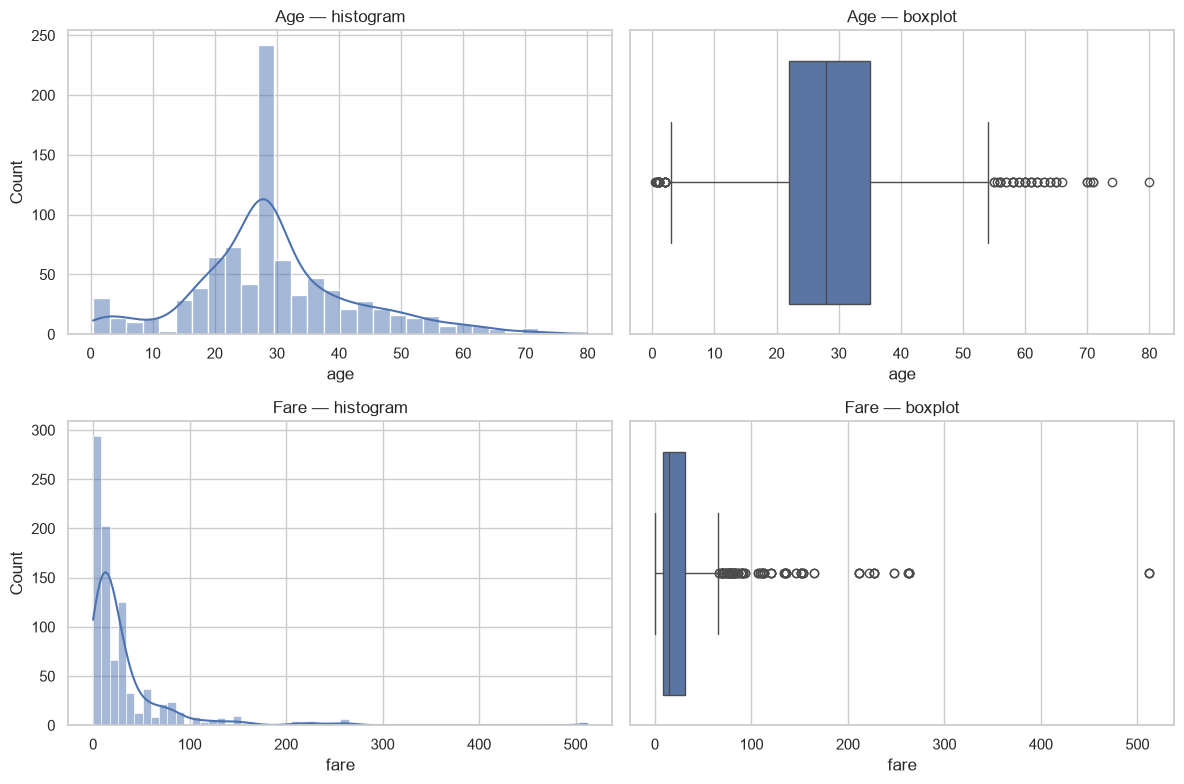

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["age"], kde=True, ax=axes[0, 0]); axes[0, 0].set_title("Age — histogram")
sns.boxplot(x=df["age"], ax=axes[0, 1]);        axes[0, 1].set_title("Age — boxplot")
sns.histplot(df["fare"], kde=True, ax=axes[1, 0]); axes[1, 0].set_title("Fare — histogram")
sns.boxplot(x=df["fare"], ax=axes[1, 1]);        axes[1, 1].set_title("Fare — boxplot")
plt.tight_layout(); plt.savefig("plots/age_fare_univariate.png", dpi=110); plt.show()

In [7]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lo) | (series > hi)).sum())

print("Age outliers (IQR rule):", iqr_outliers(df["age"]))
print("Fare outliers (IQR rule):", iqr_outliers(df["fare"]))

Age outliers (IQR rule): 65
Fare outliers (IQR rule): 114


In [8]:
fare_mean   = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode   = df["fare"].mode().iloc[0]
print(f"fare  mean={fare_mean:.2f}  median={fare_median:.2f}  mode={fare_mode:.2f}")
print(f"Skewness = {df['fare'].skew():.3f}")

fare  mean=32.10  median=14.45  mode=8.05
Skewness = 4.801


**Interpretation:** fare is **right-skewed** — mean (32.10) > median (14.45) >
mode (8.05), and skewness is positive (~4.8). A small number of very
expensive tickets pull the mean above the median.

## Task 4 — Bivariate analysis

In [9]:
# (a) survival by sex
print("Survival by sex:")
print(df.groupby("sex")["survived"].mean().round(4))

# (b) survival by pclass
print("\nSurvival by pclass:")
print(df.groupby("pclass")["survived"].mean().round(4))

# (c) survival by sex AND pclass (boolean masks)
print("\nSurvival by sex + pclass:")
for s in ["female", "male"]:
    for p in [1, 2, 3]:
        mask = (df["sex"] == s) & (df["pclass"] == p)
        print(f"  sex={s:6s} pclass={p}  n={mask.sum():3d}  survival={df.loc[mask,'survived'].mean():.3f}")

Survival by sex:
sex
female    0.7404
male      0.1889
Name: survived, dtype: float64

Survival by pclass:
pclass
1    0.6262
2    0.4728
3    0.2424
Name: survived, dtype: float64

Survival by sex + pclass:
  sex=female pclass=1  n= 92  survival=0.967
  sex=female pclass=2  n= 76  survival=0.921
  sex=female pclass=3  n=144  survival=0.500
  sex=male   pclass=1  n=122  survival=0.369
  sex=male   pclass=2  n=108  survival=0.157
  sex=male   pclass=3  n=347  survival=0.135


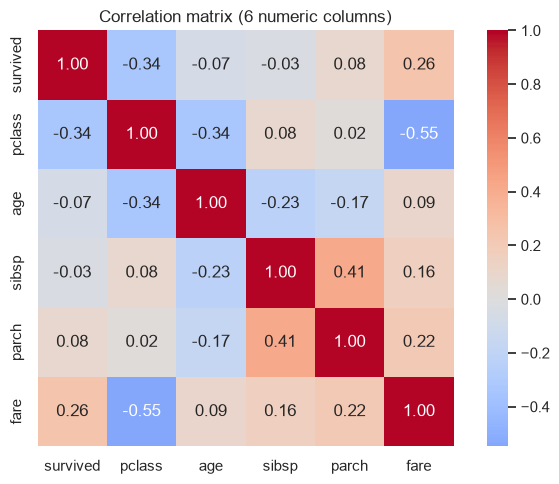

Top 2 strongest correlations:
    A      B         r
 fare pclass -0.548193
parch  sibsp  0.414542


In [10]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (6 numeric columns)")
plt.tight_layout(); plt.savefig("plots/correlation_heatmap.png", dpi=110); plt.show()

# top-2 strongest OFF-DIAGONAL correlations by |r|
pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
        .stack()
        .rename_axis(["A", "B"])
        .reset_index(name="r")
)
pairs["abs_r"] = pairs["r"].abs()
pairs = pairs[pairs["A"] < pairs["B"]].sort_values("abs_r", ascending=False)
print("Top 2 strongest correlations:")
print(pairs.head(2)[["A", "B", "r"]].to_string(index=False))

**Top-2 correlations:** `sibsp` ↔ `parch` (r ≈ +0.41) — both count family
members aboard, so naturally correlated. `pclass` ↔ `fare` (r ≈ −0.55) —
first-class passengers paid higher fares, so higher class (lower pclass
number) means higher fare. `adult_male` and `alone` are excluded as derived
flags (redundant with `sex`/`age` and `sibsp`+`parch`).

## Task 5 — Multivariate data story (≥ 4 charts with interpretation)

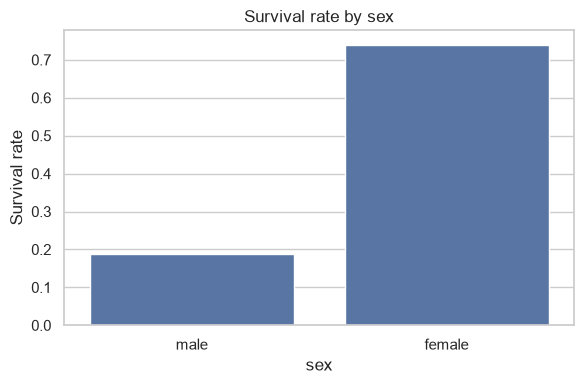

In [11]:
# Chart 1 — survival by sex
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="sex", y="survived", errorbar=None)
plt.title("Survival rate by sex"); plt.ylabel("Survival rate")
plt.tight_layout(); plt.savefig("plots/survival_by_sex.png", dpi=110); plt.show()

**Chart 1:** Females survived at ~74%, males at ~19%. Sex is the single
strongest predictor — this drives the "women and children first" pattern.

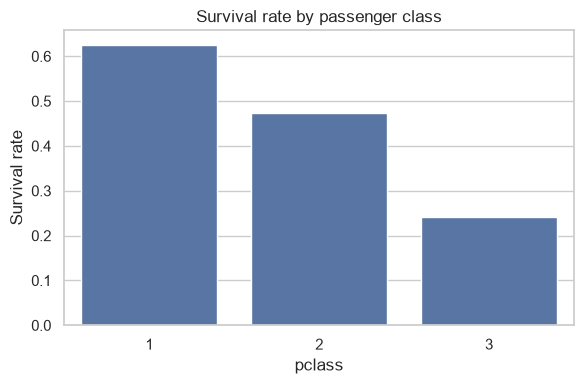

In [12]:
# Chart 2 — survival by pclass
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="pclass", y="survived", errorbar=None)
plt.title("Survival rate by passenger class"); plt.ylabel("Survival rate")
plt.tight_layout(); plt.savefig("plots/survival_by_pclass.png", dpi=110); plt.show()

**Chart 2:** First class survived ~63%, second ~47%, third ~24%. Higher
socio-economic status meant closer access to lifeboats.

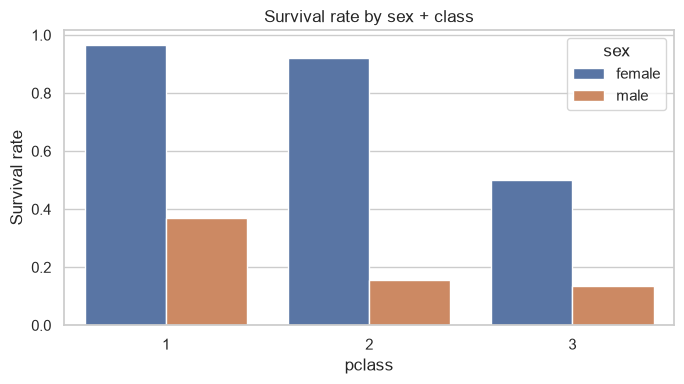

In [13]:
# Chart 3 — survival by sex AND class
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival rate by sex + class"); plt.ylabel("Survival rate")
plt.tight_layout(); plt.savefig("plots/survival_by_sex_pclass.png", dpi=110); plt.show()

**Chart 3:** Female survival is high across all classes but highest in
1st/2nd (~95%+); male survival is low everywhere, but 1st-class males (~37%)
do far better than 3rd-class males (~14%). Class still matters, especially
for men.

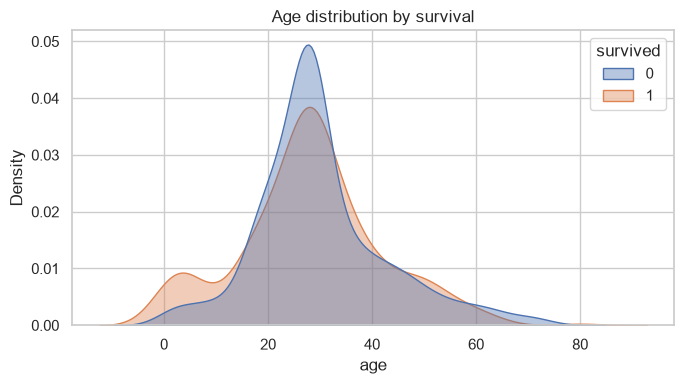

In [14]:
# Chart 4 — age distribution by survival
plt.figure(figsize=(7, 4))
sns.kdeplot(data=df, x="age", hue="survived", fill=True, common_norm=False, alpha=0.4)
plt.title("Age distribution by survival")
plt.tight_layout(); plt.savefig("plots/age_by_survival.png", dpi=110); plt.show()

**Chart 4:** Survivors show a strong spike for young children (0–10) and
generally younger adults. Older passengers (60+) skew more toward non-survival,
consistent with a children-first evacuation.

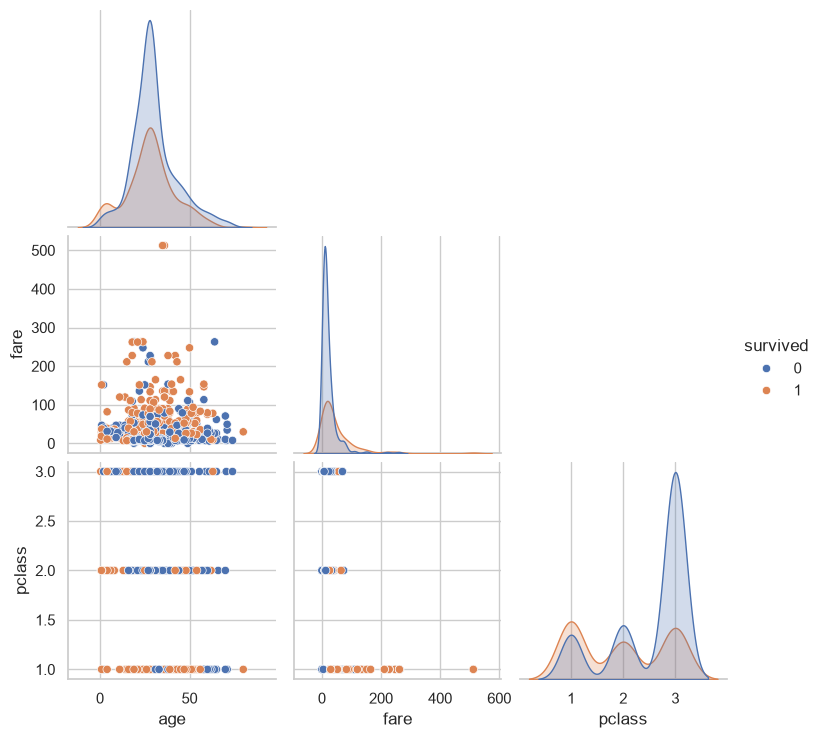

In [15]:
# Chart 5 — pairplot of key features
pp = sns.pairplot(df[["survived", "age", "fare", "pclass"]].dropna(),
                  hue="survived", corner=True, diag_kind="kde")
pp.savefig("plots/pairplot.png", dpi=90)
plt.show()

**Chart 5 (pairplot):** Reinforces earlier findings — survival clusters
around lower pclass numbers and higher fares; age overlaps more between
classes of survival, showing age is a weaker standalone signal.

## Task 6 — Exploratory standardization check

In [16]:
scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[["age", "fare"]]),
    columns=["age_z", "fare_z"],
)

print("BEFORE:")
print(df[["age", "fare"]].agg(["mean", "std"]).round(4))
print("\nAFTER (z-scored):")
print(scaled.agg(["mean", "std"]).round(4))

BEFORE:
          age     fare
mean  29.3152  32.0967
std   12.9849  49.6975

AFTER (z-scored):
       age_z  fare_z
mean  0.0000  0.0000
std   1.0006  1.0006


The z-scored columns now have mean ≈ 0 and std ≈ 1 (up to floating-point
precision), confirming the transform works. This is an EDA sanity check only
— the modeling pipeline in Notebook 2 does its own train-only scaling.